Đang khởi tạo dữ liệu và bơm nhiễu...
--> [AUTO DETECT] Sàn nhiễu bắt đầu từ chiều thứ 8.
--> Số chiều bản chất (Effective Rank) xác định được: d = 7
--> Năng lượng động lực học giữ lại: 97.37%
Đang kết xuất biểu đồ...


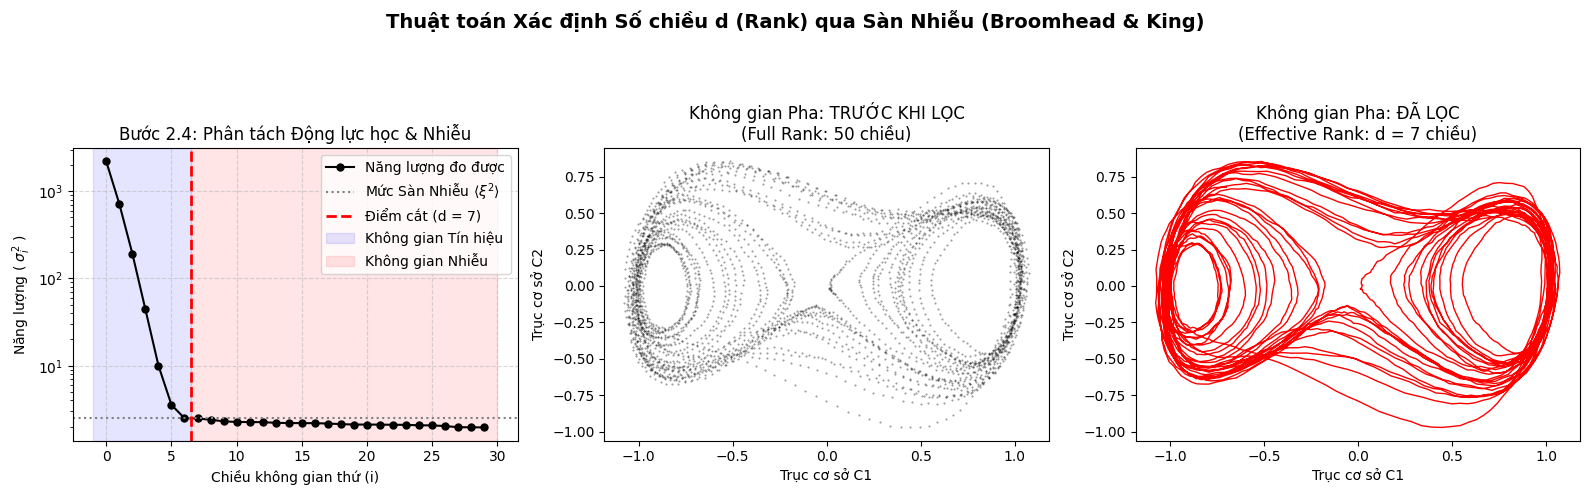

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd

# Khai báo đường dẫn module gốc
sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise

# =====================================================================
# 1. ĐẦU VÀO (INPUT)
# =====================================================================
print("Đang khởi tạo dữ liệu và bơm nhiễu...")

# Lấy trục X của Lorenz và bơm nhiễu trắng (SNR = 15 dB)
lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)
clean_x = lorenz_data[0]
noisy_x = add_white_noise(clean_x, snr_db=15.0)
N_T = len(noisy_x)

# Siêu tham số
n = 50      # Kích thước cửa sổ (Không gian quan sát 50 chiều)
J = 1       # Độ trễ trượt
N = N_T - (n - 1)

# =====================================================================
# 2. QUÁ TRÌNH (PROCESS)
# =====================================================================

# Bước 2.1: Nhúng Không gian trễ -> Tạo Ma trận Quỹ đạo X
X = np.zeros((N, n))
for i in range(N):
    X[i, :] = noisy_x[i : i + n]

X = X / np.sqrt(N) # Chuẩn hóa thành Trung bình thống kê

# Bước 2.2 & 2.3: Phân tích SVD
U, s, Vh = svd(X, full_matrices=False)

# Năng lượng (Trị riêng của ma trận Hiệp phương sai Xi)
eigenvalues = s**2

# =====================================================================
# BƯỚC 2.4: THUẬT TOÁN TỰ ĐỘNG TÌM HẠNG (EFFECTIVE RANK) BẰNG GRADIENT
# =====================================================================
# 1. Chuyển phổ năng lượng sang thang logarit (Mô phỏng trục Y của đồ thị)
log_evals = np.log10(eigenvalues)

# 2. Tính đạo hàm bậc 1 (độ dốc) giữa các điểm liên tiếp
# Hàm np.diff tính: slopes[i] = log_evals[i+1] - log_evals[i]
slopes = np.diff(log_evals)

# 3. Đặt ngưỡng nhận diện Sàn nhiễu (Scree Threshold)
# Độ dốc > -0.05 nghĩa là năng lượng giảm rất chậm (đồ thị bắt đầu phẳng lỳ)
slope_threshold = -0.05 

# 4. Tìm vị trí đầu tiên mà đồ thị phẳng ra
flat_indices = np.where(slopes > slope_threshold)[0]

if len(flat_indices) > 0:
    # +1 vì Python đếm từ 0, và +1 vì np.diff làm mảng ngắn đi 1 phần tử
    d = flat_indices[0] + 1 
else:
    d = 10 # Giá trị an toàn (fallback) nếu nhiễu quá phức tạp

print(f"--> [AUTO DETECT] Sàn nhiễu bắt đầu từ chiều thứ {d + 1}.")
print(f"--> Số chiều bản chất (Effective Rank) xác định được: d = {d}")

# Tính toán tỷ lệ năng lượng thực sự được giữ lại
total_energy = np.sum(eigenvalues)
captured_energy = np.sum(eigenvalues[:d]) / total_energy
print(f"--> Năng lượng động lực học giữ lại: {captured_energy*100:.2f}%")

# =====================================================================
# Bước 2.5: Cắt tỉa (Bỏ Sàn nhiễu) và Chiếu không gian
# =====================================================================
U_clean = U[:, :d]
s_clean = s[:d]
Vh_clean = Vh[:d, :]

# =====================================================================
# 3. ĐẦU RA (OUTPUT) & TRỰC QUAN HÓA
# =====================================================================
print("Đang kết xuất biểu đồ...")

fig = plt.figure(figsize=(16, 5))
fig.suptitle("Thuật toán Xác định Số chiều d (Rank) qua Sàn Nhiễu (Broomhead & King)", fontsize=14, fontweight='bold', y=0.98)

# --- Đồ thị 1: Phổ Trị riêng & Điểm gãy (Knee-point) ---
ax1 = fig.add_subplot(131)
ax1.plot(eigenvalues[:30], 'ko-', markersize=5, label='Năng lượng đo được') 
ax1.set_yscale('log')
ax1.set_title("Bước 2.4: Phân tách Động lực học & Nhiễu", fontsize=12)
ax1.set_xlabel("Chiều không gian thứ (i)")
ax1.set_ylabel(r"Năng lượng ( $\sigma_i^2$ )")

# Vẽ đường thẳng minh họa Sàn nhiễu
noise_floor_level = eigenvalues[d]
ax1.axhline(y=noise_floor_level, color='gray', linestyle=':', label=r'Mức Sàn Nhiễu $\langle \xi^2 \rangle$')
ax1.axvline(x=d-0.5, color='red', linestyle='--', linewidth=2, label=f"Điểm cắt (d = {d})")

# Đổ màu phân biệt
ax1.axvspan(-1, d-0.5, alpha=0.1, color='blue', label='Không gian Tín hiệu')
ax1.axvspan(d-0.5, 30, alpha=0.1, color='red', label='Không gian Nhiễu')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Đồ thị 2: Không gian Pha bị nhiễu (Dữ liệu Thô) ---
PCs_noisy = X @ Vh.T
ax2 = fig.add_subplot(132)
ax2.plot(PCs_noisy[:, 0], PCs_noisy[:, 1], 'k.', markersize=1, alpha=0.4)
ax2.set_title(f"Không gian Pha: TRƯỚC KHI LỌC\n(Full Rank: {n} chiều)", fontsize=12)
ax2.set_xlabel("Trục cơ sở C1")
ax2.set_ylabel("Trục cơ sở C2")

# --- Đồ thị 3: Không gian Pha sạch (Đầu ra) ---
ax3 = fig.add_subplot(133)
ax3.plot(U_clean[:, 0] * s_clean[0], U_clean[:, 1] * s_clean[1], 'r-', linewidth=1.0)
ax3.set_title(f"Không gian Pha: ĐÃ LỌC\n(Effective Rank: d = {d} chiều)", fontsize=12)
ax3.set_xlabel("Trục cơ sở C1")
ax3.set_ylabel("Trục cơ sở C2")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

Đang tạo dữ liệu và mô phỏng nhiễu phi trắng...
Đang phân tích SSA và vẽ phổ năng lượng...


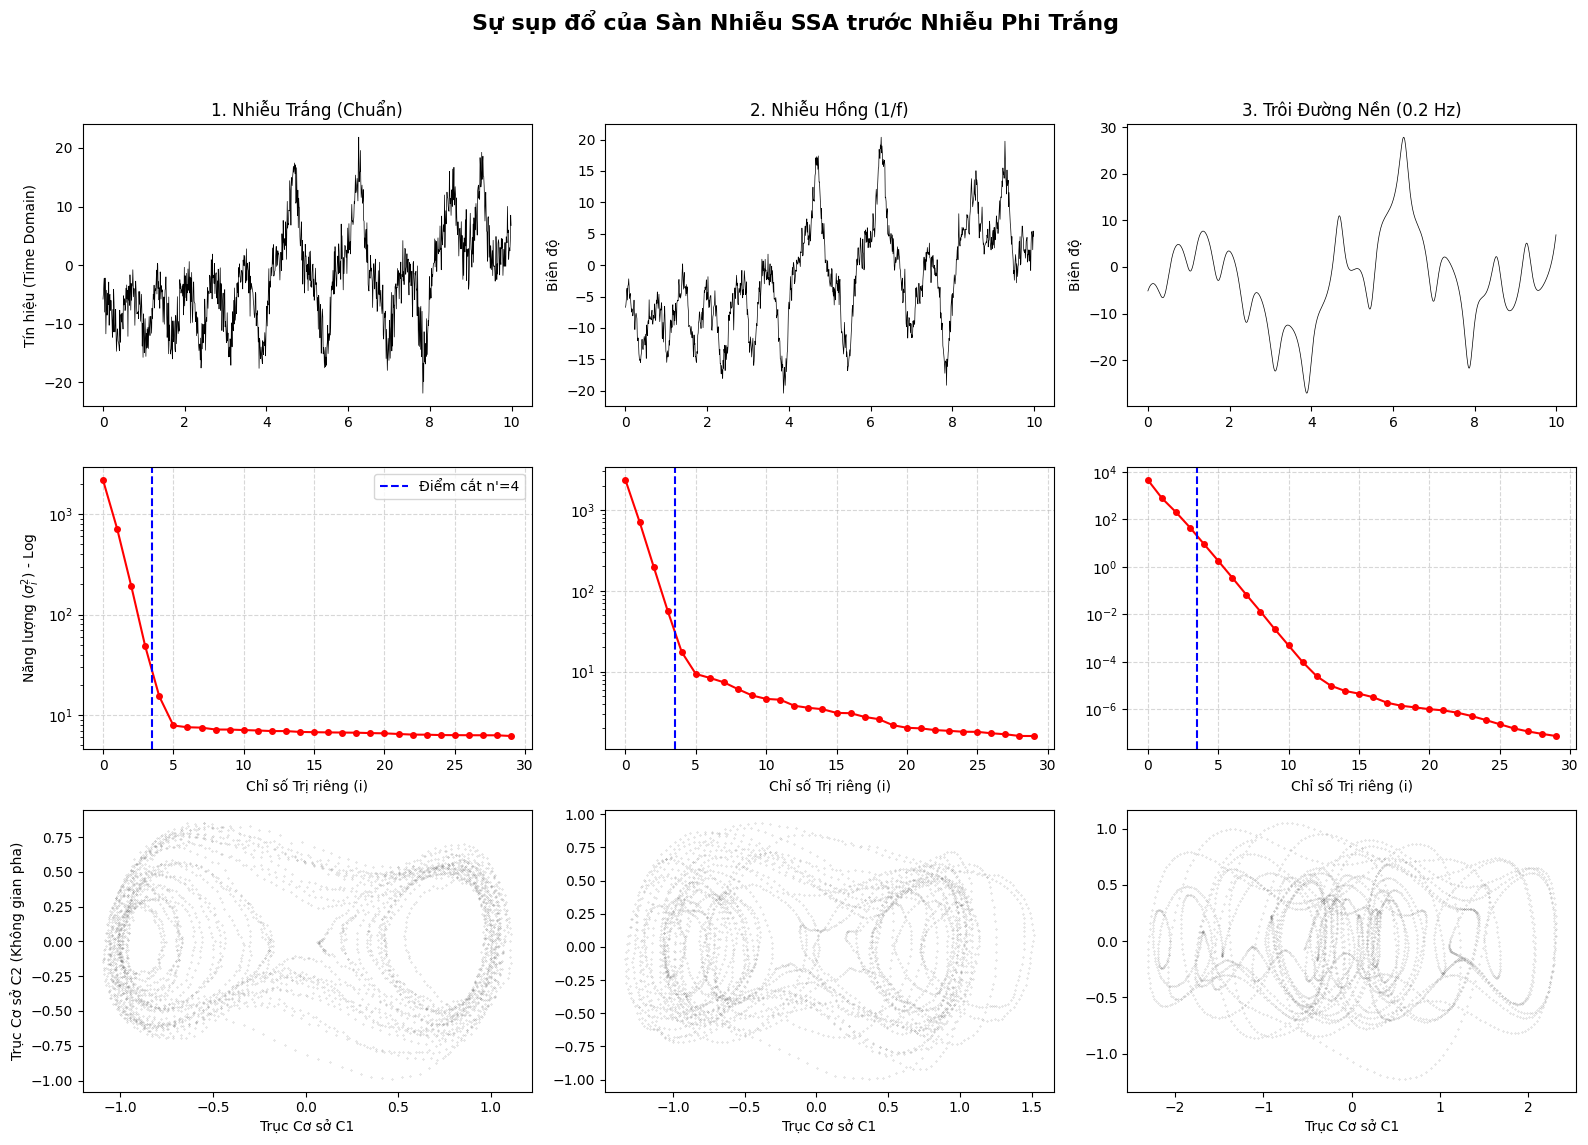

In [5]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd

# Khai báo đường dẫn module gốc
sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise, add_colored_noise, add_baseline_wander

# =====================================================================
# 1. HÀM TIỆN ÍCH (HELPER FUNCTION) ĐỂ CHẠY SSA
# =====================================================================
def apply_ssa(noisy_signal, n_window=50):
    N_T = len(noisy_signal)
    N = N_T - (n_window - 1)
    
    # Tạo ma trận quỹ đạo X
    X = np.zeros((N, n_window))
    for i in range(N):
        X[i, :] = noisy_signal[i : i + n_window]
    X = X / np.sqrt(N)
    
    # SVD Tinh gọn
    U, s, Vh = svd(X, full_matrices=False)
    eigenvalues = s**2
    return U, s, Vh, eigenvalues, X

# =====================================================================
# 2. KHỞI TẠO DỮ LIỆU & 3 KỊCH BẢN NHIỄU
# =====================================================================
print("Đang tạo dữ liệu và mô phỏng nhiễu phi trắng...")
sampling_rate = 100.0
lorenz_data = simulate_lorenz(t_span=50.0, dt=1.0/sampling_rate)
clean_x = lorenz_data[0]
t = np.arange(len(clean_x)) / sampling_rate

# Kịch bản 1: Nhiễu trắng (SNR = 10 dB)
signal_white = add_white_noise(clean_x, snr_db=10.0)

# Kịch bản 2: Nhiễu hồng 1/f (SNR = 10 dB)
signal_pink = add_colored_noise(clean_x, snr_db=10.0, color='pink')

# Kịch bản 3: Trôi đường nền (Tần số 0.2 Hz, biên độ gấp 1.5 lần tín hiệu gốc)
signal_wander = add_baseline_wander(clean_x, frequency=0.2, sampling_rate=sampling_rate, amplitude_ratio=1.5)

# Đưa vào danh sách để lặp
signals = [signal_white, signal_pink, signal_wander]
titles = ["1. Nhiễu Trắng (Chuẩn)", "2. Nhiễu Hồng (1/f)", "3. Trôi Đường Nền (0.2 Hz)"]

# =====================================================================
# 3. CHẠY THUẬT TOÁN SSA & TRỰC QUAN HÓA (3x3 Grid)
# =====================================================================
print("Đang phân tích SSA và vẽ phổ năng lượng...")
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Sự sụp đổ của Sàn Nhiễu SSA trước Nhiễu Phi Trắng", fontsize=16, fontweight='bold', y=0.95)

n_window = 50
n_prime_plot = 4 # Điểm cắt giả định để giữ lại n' chiều

for col in range(3):
    # Lấy tín hiệu theo kịch bản
    sig = signals[col]
    title = titles[col]
    
    # Chạy SSA
    U, s, Vh, eigenvalues, X = apply_ssa(sig, n_window)
    
    # --- Hàng 1: Tín hiệu miền thời gian ---
    ax_time = axes[0, col]
    ax_time.plot(t[:1000], sig[:1000], 'k-', lw=0.5) # Chỉ vẽ 10 giây đầu cho dễ nhìn
    ax_time.set_title(title, fontsize=12)
    ax_time.set_ylabel("Biên độ")
    if col == 0: ax_time.set_ylabel("Tín hiệu (Time Domain)")
    
    # --- Hàng 2: Phổ Giá trị Suy biến (Singular Spectrum) ---
    ax_spec = axes[1, col]
    ax_spec.plot(eigenvalues[:30], 'ro-', markersize=4)
    ax_spec.set_yscale('log')
    ax_spec.set_xlabel("Chỉ số Trị riêng (i)")
    ax_spec.axvline(x=n_prime_plot-0.5, color='blue', linestyle='--', label=f"Điểm cắt n'={n_prime_plot}")
    ax_spec.grid(True, linestyle='--', alpha=0.5)
    if col == 0: 
        ax_spec.set_ylabel(r"Năng lượng ($\sigma_i^2$) - Log")
        ax_spec.legend()
        
    # --- Hàng 3: Không gian Pha Tái tạo (Chiếu lên C1, C2) ---
    # Chiếu dữ liệu X lên 2 vector cơ sở đầu tiên Vh[0] và Vh[1]
    ax_phase = axes[2, col]
    PCs = X @ Vh.T
    ax_phase.plot(PCs[:, 0], PCs[:, 1], 'k.', markersize=0.5, alpha=0.3)
    ax_phase.set_xlabel("Trục Cơ sở C1")
    if col == 0: ax_phase.set_ylabel("Trục Cơ sở C2 (Không gian pha)")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

Đang sinh dữ liệu Lorenz...
Đang vẽ biểu đồ phân tích...


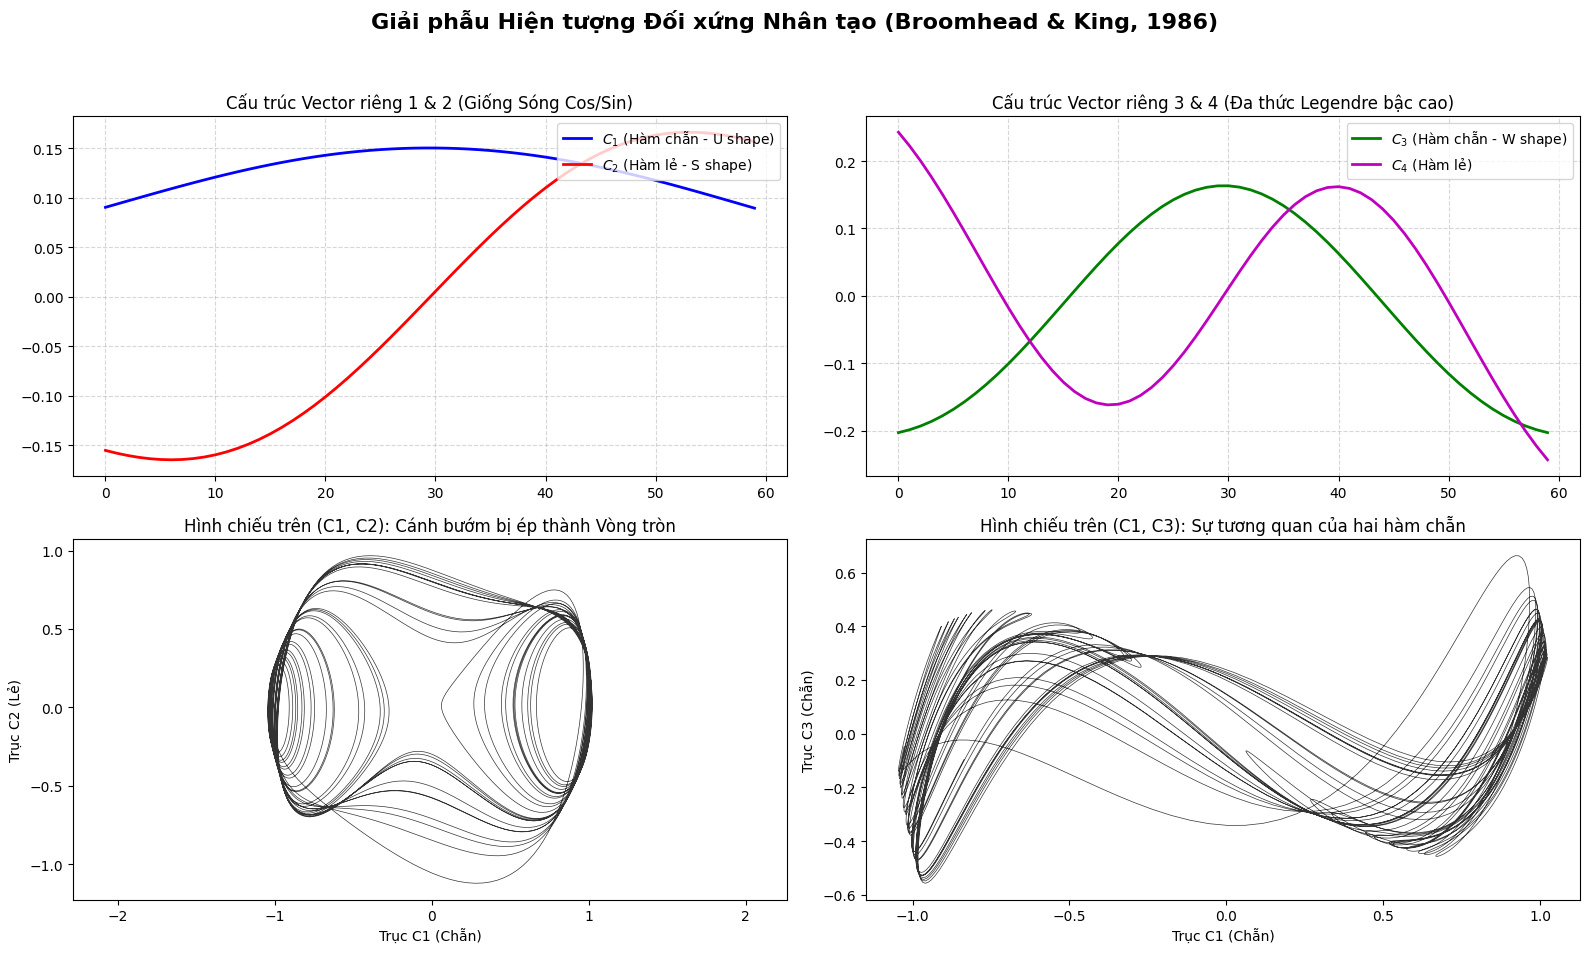

In [6]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd

# Khai báo đường dẫn module gốc
sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz

# =====================================================================
# 1. KHỞI TẠO DỮ LIỆU LORENZ SẠCH
# =====================================================================
print("Đang sinh dữ liệu Lorenz...")
sampling_rate = 100.0
lorenz_data = simulate_lorenz(t_span=50.0, dt=1.0/sampling_rate)
clean_x = lorenz_data[0]

# =====================================================================
# 2. XÂY DỰNG MA TRẬN QUỸ ĐẠO & CHẠY SVD
# =====================================================================
# Chọn cửa sổ n=60 (đủ dài để hiện tượng đối xứng bùng phát rõ rệt)
n_window = 60
N_T = len(clean_x)
N = N_T - (n_window - 1)

X = np.zeros((N, n_window))
for i in range(N):
    X[i, :] = clean_x[i : i + n_window]
X = X / np.sqrt(N)

# Chạy SVD tinh gọn
U, s, Vh = svd(X, full_matrices=False)

# =====================================================================
# 3. TRỰC QUAN HÓA: BÓC TÁCH HIỆN TƯỢNG "ĐỐI XỨNG NHÂN TẠO"
# =====================================================================
print("Đang vẽ biểu đồ phân tích...")
fig = plt.figure(figsize=(16, 10))
fig.suptitle("Giải phẫu Hiện tượng Đối xứng Nhân tạo (Broomhead & King, 1986)", 
             fontsize=16, fontweight='bold', y=0.95)

# --- PHẦN 1: HÌNH DÁNG CỦA 4 VECTOR CƠ SỞ ĐẦU TIÊN (Eigenvectors) ---
# Vh chứa các vector cơ sở trên các hàng. Kích thước mỗi vector là n_window
t_window = np.arange(n_window)

ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(t_window, Vh[0, :], 'b-', linewidth=2, label=r'$C_1$ (Hàm chẵn - U shape)')
ax1.plot(t_window, Vh[1, :], 'r-', linewidth=2, label=r'$C_2$ (Hàm lẻ - S shape)')
ax1.set_title("Cấu trúc Vector riêng 1 & 2 (Giống Sóng Cos/Sin)", fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(t_window, Vh[2, :], 'g-', linewidth=2, label=r'$C_3$ (Hàm chẵn - W shape)')
ax2.plot(t_window, Vh[3, :], 'm-', linewidth=2, label=r'$C_4$ (Hàm lẻ)')
ax2.set_title("Cấu trúc Vector riêng 3 & 4 (Đa thức Legendre bậc cao)", fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

# --- PHẦN 2: SỰ BÓP MÉO QUỸ ĐẠO BỞI TỌA ĐỘ MỚI ---
# Chiếu dữ liệu X lên các trục cơ sở (Tương đương tính Principal Components)
PCs = X @ Vh.T

ax3 = fig.add_subplot(2, 2, 3)
# Vẽ cánh bướm Lorenz bị ép lên trục C1 (Cos) và C2 (Sin)
ax3.plot(PCs[:, 0], PCs[:, 1], 'k-', lw=0.5, alpha=0.8)
ax3.set_title("Hình chiếu trên (C1, C2): Cánh bướm bị ép thành Vòng tròn", fontsize=12)
ax3.set_xlabel("Trục C1 (Chẵn)")
ax3.set_ylabel("Trục C2 (Lẻ)")
ax3.axis('equal') # Ép tỷ lệ 1:1 để thấy rõ độ tròn

ax4 = fig.add_subplot(2, 2, 4)
# Vẽ trên trục C1 (Chẵn) và C3 (Chẵn) -> Tạo ra hình dạng gấp khúc kỳ lạ
ax4.plot(PCs[:, 0], PCs[:, 2], 'k-', lw=0.5, alpha=0.8)
ax4.set_title("Hình chiếu trên (C1, C3): Sự tương quan của hai hàm chẵn", fontsize=12)
ax4.set_xlabel("Trục C1 (Chẵn)")
ax4.set_ylabel("Trục C3 (Chẵn)")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()